In [2]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import anndata as ad
import pertpy as pt
import scanpy as sc
import numpy as np
import pandas as pd
import math
import seaborn as sns

sccoda_model = pt.tl.Sccoda()

In [3]:
adata_age_nk= sc.read_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_nk_combined_annot_with_age_scvi.h5ad")

In [4]:
adata_age_nk

AnnData object with n_obs × n_vars = 207458 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age (years)', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age i

In [5]:
adata_age_nk.obs["Age_group"].value_counts().sort_index()

Age_group
0–3      43157
4–6      52937
7–10     36738
11–14    55902
15–18    18724
Name: count, dtype: int64

In [6]:
adata_age_nk.obs["Age (years)"].value_counts().sort_index()

Age (years)
0.05     2551
0.07     1286
0.14      838
0.35      844
0.48      965
         ... 
16.16    1325
16.20    1371
16.29     641
16.78    1348
17.03    1763
Name: count, Length: 122, dtype: int64

In [7]:
adata_age_nk.obs["Sex"].value_counts().sort_index()

Sex
Female     78778
Male      128680
Name: count, dtype: int64

In [8]:
adata_age_nk.obs["Age"].value_counts().sort_index()

Age
0     13013
1      6502
2      9873
3     13769
4     21383
5     16473
6     15081
7     14284
8     11152
9      7427
10     3875
11    14692
12     8644
13    13454
14    19112
15    10990
16     5971
17     1763
Name: count, dtype: int64

In [9]:
adata_age_nk.obs['pica_cell_type_complete_01_gdT_corrected'].unique()
adata_age_nk.obs['pica_cell_type_complete_01_gdT_corrected'].value_counts()

pica_cell_type_complete_01_gdT_corrected
CD56_dim CD16+ NK           171221
ILC1                         16331
CD56_dim CD16+ KLRC2+ NK     15081
iILC2                         2400
nILC2                         1554
CD56_bright CD16- NK           871
Name: count, dtype: int64

In [10]:
adata_age_nk.obs['Batch'] = adata_age_nk.obs['sequencing_batch'].map(
        {
            '20240530_WGS_20240530_sc_PICA0001-PICA0007': "Batch01",
            '20240918_WGS_20240924_sc_PICA0008-PICA0032': "Batch02",
            '20241106_WGS_20241106_sc_PICA0033-PICA0069': "Batch03",
            '20250114_WGS_20241218_sc_PICA0071-PICA0097': "Batch04",
            '20250324_WGS_20250324_sc_PICA0098-PICA0118': "Batch05",
            '20250612_WGS_20250612_sc_PICA0119-PICA0146': "Batch06",
            '20250814_WGS_20250814_sc_PICA0147-PICA0173': "Batch07"
        }
    )

adata_age_nk.obs["Age_group"] = pd.Categorical(
        adata_age_nk.obs["Age_group"],
        categories=["0–3", "4–6", "7–10", "11–14", "15–18"],
        ordered=True,
    )
"""
#centre age (compute difference between sex at different age)
adata_age_nk.obs["Age_years"] = (
    adata_age_nk.obs["Age (years)"]
    - adata_age_nk.obs["Age (years)"].mean()
)
"""
adata_age_nk.obs = adata_age_nk.obs.rename(columns={
    "Age (years)": "Age_years"
})

adata_age_nk.obs["Batch"] = adata_age_nk.obs["Batch"].astype("category")
adata_age_nk.obs["Age_years"] = adata_age_nk.obs["Age_years"].astype("float")
adata_age_nk.obs["Sex"] = adata_age_nk.obs["Sex"].astype("category")
adata_age_nk.obs["Age"] = adata_age_nk.obs["Age"].astype("int")

In [11]:
adata_age_nk.obs["Age_years"].value_counts().sort_index()

Age_years
0.05     2551
0.07     1286
0.14      838
0.35      844
0.48      965
         ... 
16.16    1325
16.20    1371
16.29     641
16.78    1348
17.03    1763
Name: count, Length: 122, dtype: int64

In [12]:
adata_age_nk.obs["Batch"].value_counts().sort_index()

Batch
Batch01     6806
Batch02    42959
Batch03    36939
Batch04    39523
Batch05    23212
Batch06    33084
Batch07    24935
Name: count, dtype: int64

In [13]:
adata_age_nk.obs.groupby("pica_id")["Age_years"].unique()

pica_id
PICA0001     [2.09]
PICA0002    [15.09]
PICA0003     [0.83]
PICA0004     [1.46]
PICA0005      [9.3]
             ...   
PICA0164     [2.15]
PICA0166     [0.62]
PICA0168     [16.2]
PICA0169     [2.72]
PICA0173    [15.31]
Name: Age_years, Length: 128, dtype: object

In [14]:
adata_age_nk.obs.drop_duplicates(subset="pica_id").groupby(["Age_years", "Sex"]).size().reset_index(name="n_donors")

,Age_years,Sex,n_donors
0,0.05,Female,0
1,0.05,Male,1
2,0.07,Female,1
3,0.07,Male,0
4,0.14,Female,0
...,...,...,...
239,16.29,Male,1
240,16.78,Female,0
241,16.78,Male,1
242,17.03,Female,1


In [15]:
adata_age_nk.obs.drop_duplicates(subset="pica_id").groupby(["Age", "Sex"]).size().reset_index(name="n_donors")

,Age,Sex,n_donors
0,0,Female,3
1,0,Male,7
2,1,Female,1
3,1,Male,4
4,2,Female,1
5,2,Male,7
6,3,Female,6
7,3,Male,2
8,4,Female,6
9,4,Male,6


In [16]:
""" Age group
# build sccoda input from cell-level data
def make_sccoda_from_lineage(
    adata,
    cell_type_col="cell_type",   
    sample_col="pica_id",       
    covariates=("Age_group","Child's sex"), 
):
    sccoda_data = sccoda_model.load(
        adata,
        type="cell_level",
        generate_sample_level=True,
        cell_type_identifier=cell_type_col,
        sample_identifier=sample_col,
        covariate_obs=list(covariates),
    )
    return sccoda_data
""" 

' Age group\n# build sccoda input from cell-level data\ndef make_sccoda_from_lineage(\n    adata,\n    cell_type_col="cell_type",   \n    sample_col="pica_id",       \n    covariates=("Age_group","Child\'s sex"), \n):\n    sccoda_data = sccoda_model.load(\n        adata,\n        type="cell_level",\n        generate_sample_level=True,\n        cell_type_identifier=cell_type_col,\n        sample_identifier=sample_col,\n        covariate_obs=list(covariates),\n    )\n    return sccoda_data\n'

In [17]:
# build sccoda input from cell-level data
def make_sccoda_from_lineage(
    adata,
    cell_type_col="pica_cell_type_complete_01_gdT_corrected",   
    sample_col="pica_id",       
    covariates=("Age_years","Sex", "Batch", "Age"), 
):
    sccoda_data = sccoda_model.load(
        adata,
        type="cell_level",
        generate_sample_level=True,
        cell_type_identifier=cell_type_col,
        sample_identifier=sample_col,
        covariate_obs=list(covariates),
    )
    return sccoda_data

In [18]:
sccoda_nk = make_sccoda_from_lineage(adata_age_nk, cell_type_col="pica_cell_type_complete_01_gdT_corrected")

In [19]:
sccoda_nk

MuData object with n_obs × n_vars = 207586 × 38612
  2 modalities
    rna:	207458 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age_in_years_int', 'Age_group', '_scvi_batch', '_scvi_labels', 'Batch', 'scCODA_sample_id'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'pica_cell_type_complete_01_gdT_corrected_colors', 'sequencing_batch_colors', 'umap'
      obsm:	'X_scVI', 'X_umap'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    coda:	128 x 6
      obs:	'Sex', 'Batch', 'Age', 'pica_id', 'Age_years'
      var:	'n_cells'

## Age only model

In [20]:
# prepare sccoda model
def prepare_sccoda_age(sccoda_data, modality_key="coda", ref="automatic"):
    formula = "Age_years * Sex + Batch"

    sccoda_data = sccoda_model.prepare(
        sccoda_data,
        modality_key=modality_key,
        formula=formula,
        reference_cell_type=ref
    )
    return sccoda_data

In [21]:
# run sccoda
def run_sccoda(sccoda_data, modality_key="coda", rng_key=0):
    sccoda_model.run_nuts(
        sccoda_data,
        modality_key=modality_key,
        num_warmup=2000,
        num_samples=5000,
        rng_key=rng_key,
    )
    return sccoda_data

#### automatic ref cell type model (nILC2)

In [ ]:
nk_auto = prepare_sccoda_age(sccoda_nk.copy(), ref="automatic")

• Automatic reference selection! Reference cell type set to nILC2
• Zero counts encountered in data! Added a pseudocount of 0.5.


In [ ]:
nk_auto = run_sccoda(nk_auto, rng_key=1)

sample: 100%|██████████| 7000/7000 [14:44<00:00,  7.92it/s, 1023 steps of size 4.72e-03. acc. prob=0.94]


In [25]:
sccoda_model.summary(sccoda_nk, modality_key="coda", extended=True)

                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 128 samples, 6 cell types                                         │
│ Reference cell type                   │ nILC2                                                                   │
│ Formula                               │ Age_years * Sex + Batch                                                 │
│ Reference index                       │ 5                                                                       │
│ Spike-and-slab threshold              │ 0.816                                                                   │
│ Spike-and-slab threshold              │ 0.816                                                                   │
│ MCMC Sampling                         │ Sampled 5000 chain states (2000 burnin samples)                         │
│ Acceptance rate                       │ 94.5%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                           Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample               │
│ pica_cell_type_complete_01_gdT_corrected                                                                        │
│ CD56_bright CD16- NK                          -1.372       -1.678  -1.082  0.160        6.878                   │
│ CD56_dim CD16+ KLRC2+ NK                       0.867        0.503   1.247  0.197       64.546                   │
│ CD56_dim CD16+ NK                              3.917        3.451   4.322  0.250     1362.911                   │
│ ILC1                                           1.664        1.303   2.080  0.211      143.219                   │
│ iILC2                                         -0.115       -0.427   0.227  0.181       24.176                   │
│ nILC2                                         -0.335       -0.502  -0.178  0.087       19.402                   │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                               Final Parameter  Expected Sample  log2-fold change                │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD56_bright CD16- NK           0.000             6.878            0.000                     │
│                     CD56_dim CD16+ KLRC2+ NK       0.000            64.546            0.000                     │
│                     CD56_dim CD16+ NK              0.000          1362.911            0.000                     │
│                     ILC1                           0.000           143.219            0.000                     │
│                     iILC2                          0.000            24.176            0.000                     │
│                     nILC2                          0.000            19.402            0.000                     │
│ BatchT.Batch02      CD56_bright CD16- NK           0.000             6.981            0.021                     │
│                     CD56_dim CD16+ KLRC2+ NK      -0.459            41.394           -0.641                     │
│                     CD56_dim CD16+ NK              0.000          1383.182            0.021                     │
│                     ILC1                           0.000           145.350            0.021                     │
│                     iILC2                          0.000            24.536            0.021                     │
│                     nILC2                          0.000            19.691            0.021                     │
│ BatchT.Batch03      CD56_bright CD16- NK           0.908            37.608            2.451                     │
│                     CD56_dim CD16+ KLRC2+ NK       0.000           142.282            1.140                     │
│                     CD56_dim CD16+ NK             -0.912          1206.721           -0.176                     │
│                     ILC1                          -0.824           138.459           -0.049                     │
│                     iILC2                          0.000            53.293            1.140                     │
│                     nILC2                          0.000            42.769            1.140                     │
│ BatchT.Batch04      CD56_bright CD16- NK           0.000             6.878            0.000                     │
│                     CD56_dim CD16+ KLRC2+ NK       0.000            64.546            0.000                     │
│                     CD56_dim CD16+ NK              0.000          1362.911            0.000                     │
│                     ILC1                           0.000           143.219            0.000                     │
│                     iILC2                          0.000            24.176            0.000                     │
│                     nILC2                          0.000            19.402            0.000                     │
│ BatchT.Batch05      CD56_bright CD16- NK           0.000            25.135            1.870                     │
│                     CD56_dim CD16+ KLRC2+ NK       0.000           235.869            1.870                     │
│                     CD56_dim CD16+ NK             -1.575          1030.614           -0.403                     │
│                     ILC1                          -1.123           170.267            0.250                     │
│                     iILC2                          0.000            88.347            1.870                     │
│                     nILC2                          0.0

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                               HDI 3%  HDI 97%   SD   Inclusion probability                      │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD56_bright CD16- NK      -0.249   0.191  0.071         0.397                               │
│                     CD56_dim CD16+ KLRC2+ NK  -0.083   0.343  0.092         0.462                               │
│                     CD56_dim CD16+ NK         -0.040   0.266  0.081         0.525                               │
│                     ILC1                      -0.248   0.109  0.068         0.428                               │
│                     iILC2                     -0.213   0.216  0.074         0.405                               │
│                     nILC2                      0.000   0.000  0.000         0.000                               │
│ BatchT.Batch02      CD56_bright CD16- NK      -0.485   0.355  0.135         0.384                               │
│                     CD56_dim CD16+ KLRC2+ NK  -0.888   0.021  0.283         0.863                               │
│                     CD56_dim CD16+ NK         -0.185   0.733  0.216         0.512                               │
│                     ILC1                      -0.170   0.650  0.188         0.488                               │
│                     iILC2                     -0.436   0.336  0.129         0.385                               │
│                     nILC2                      0.000   0.000  0.000         0.000                               │
│ BatchT.Batch03      CD56_bright CD16- NK       0.444   1.344  0.242         0.995                               │
│                     CD56_dim CD16+ KLRC2+ NK  -0.565   0.492  0.160         0.317                               │
│                     CD56_dim CD16+ NK         -1.383  -0.419  0.259         0.997                               │
│                     ILC1                      -1.246  -0.327  0.257         0.987                               │
│                     iILC2                     -0.711   0.151  0.204         0.423                               │
│                     nILC2                      0.000   0.000  0.000         0.000                               │
│ BatchT.Batch04      CD56_bright CD16- NK      -0.365   0.444  0.126         0.356                               │
│                     CD56_dim CD16+ KLRC2+ NK  -0.799   0.154  0.249         0.551                               │
│                     CD56_dim CD16+ NK         -0.012   1.028  0.344         0.789                               │
│                     ILC1                      -0.010   0.960  0.323         0.812                               │
│                     iILC2                     -0.029   0.930  0.307         0.774                               │
│                     nILC2                      0.000   0.000  0.000         0.000                               │
│ BatchT.Batch05      CD56_bright CD16- NK      -0.925   0.158  0.246         0.401                               │
│                     CD56_dim CD16+ KLRC2+ NK  -0.005   0.942  0.326         0.740                               │
│                     CD56_dim CD16+ NK         -2.165  -0.897  0.332         1.000                               │
│                     ILC1                      -1.697  -0.508  0.319         0.994                               │
│                     iILC2                     -1.017   0.017  0.336         0.647                               │
│                     nILC2                      0.000  

In [ ]:
# set desired FDR globally
sccoda_model.set_fdr(nk_auto, est_fdr=0.1, modality_key="coda")

In [ ]:
# check threshold
nk_auto["coda"].uns["scCODA_params"]["threshold_prob"]

np.float64(0.773)

In [ ]:
effects_nk_auto = sccoda_model.get_effect_df(nk_auto, modality_key="coda")

effects_nk_auto["Inclusion probability"].max()
effects_nk_auto["Inclusion probability"].describe()

count    54.000000
mean      0.435737
std       0.317874
min       0.000000
25%       0.174350
50%       0.403800
75%       0.662850
max       1.000000
Name: Inclusion probability, dtype: float64

In [ ]:

# effects dataframe
effects_nk_auto = sccoda_model.get_effect_df(nk_auto, modality_key="coda")
effects_nk_auto.head()

Final Parameter  HDI 3%  HDI 97%     SD  \
Covariate Cell Type                                                           
SexT.Male CD56_bright CD16- NK                  0.0  -0.249    0.191  0.071   
          CD56_dim CD16+ KLRC2+ NK              0.0  -0.083    0.343  0.092   
          CD56_dim CD16+ NK                     0.0  -0.040    0.266  0.081   
          ILC1                                  0.0  -0.248    0.109  0.068   
          iILC2                                 0.0  -0.213    0.216  0.074   

                                    Inclusion probability  Expected Sample  \
Covariate Cell Type                                                          
SexT.Male CD56_bright CD16- NK                     0.3966         6.878343   
          CD56_dim CD16+ KLRC2+ NK                 0.4618        64.545981   
          CD56_dim CD16+ NK                        0.5254      1362.910615   
          ILC1                                     0.4282       143.219419   
          iILC2                                    0.4050        24.176422   

                                    log2-fold change  
Covariate Cell Type                                   
SexT.Male CD56_bright CD16- NK                   0.0  
          CD56_dim CD16+ KLRC2+ NK               0.0  
          CD56_dim CD16+ NK                      0.0  
          ILC1                                   0.0  
          iILC2                                  0.0

In [ ]:
# counts per sample x celltype
counts = pd.DataFrame(
    nk_auto["coda"].X,
    index=nk_auto["coda"].obs_names,
    columns=nk_auto["coda"].var_names,
)

# convert to proportions
props = counts.div(counts.sum(axis=1), axis=0)

# metadata (sample-level)
meta = nk_auto["coda"].obs.copy()

# long format for plotting
df = (
    props.join(meta[["Age_years", "Age"]])
    .reset_index(names="sample")
    .melt(id_vars=["sample", "Age_years", "Age"], var_name="pica_cell_type_complete_01_gdT_corrected", value_name="Proportion")
)

In [31]:
df["pica_cell_type_complete_01_gdT_corrected"].unique()

array(['CD56_bright CD16- NK', 'CD56_dim CD16+ KLRC2+ NK',
       'CD56_dim CD16+ NK', 'ILC1', 'iILC2', 'nILC2'], dtype=object)

In [32]:
df["Age"].unique()

array([ 2, 15,  0,  1,  9,  3,  4,  5, 13,  6,  7, 10, 16, 12, 11, 14,  8,
       17])

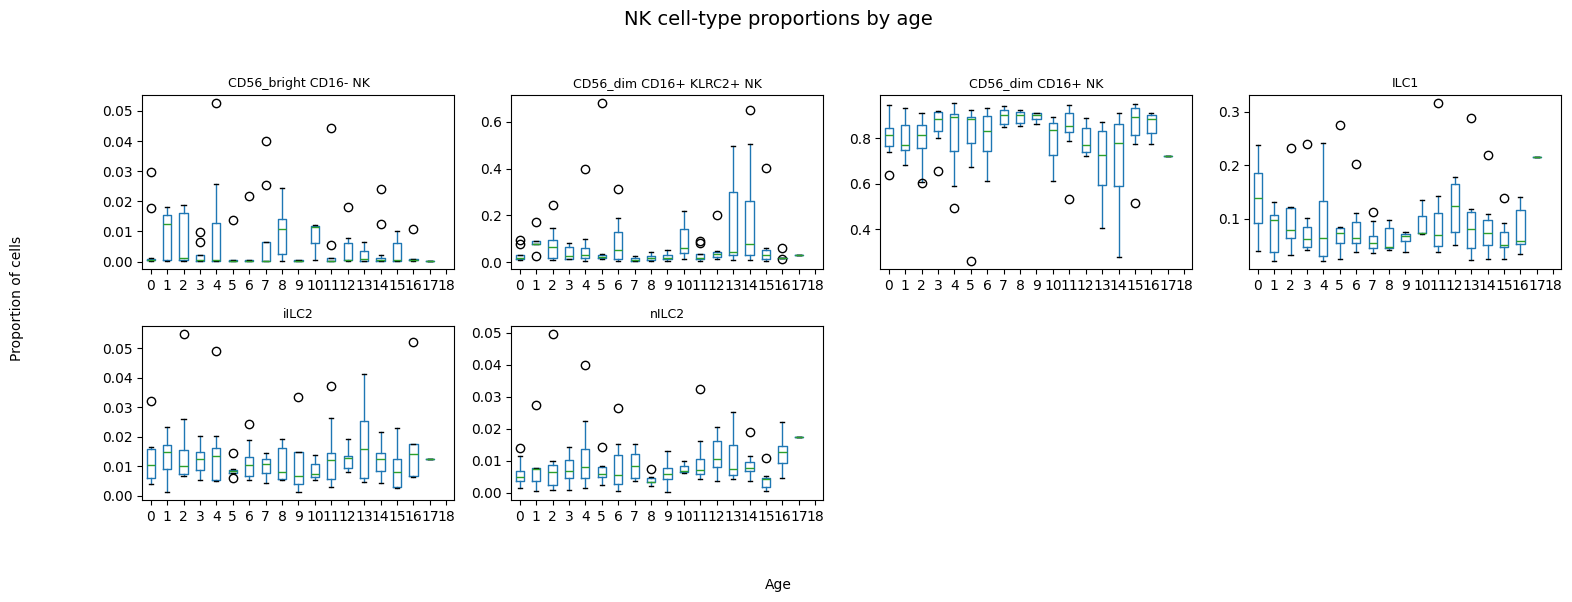

In [33]:
# boxplots of relative abundances per donor per age group
cell_types = sorted(df["pica_cell_type_complete_01_gdT_corrected"].unique())

n_cols = 4
n_rows = math.ceil(len(cell_types) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()

for ax, cell in zip(axes, cell_types):
    sub = df[df["pica_cell_type_complete_01_gdT_corrected"] == cell]
    sub.boxplot(
        column="Proportion",
        by="Age",
        grid=False,
        ax=ax
    )

    ax.set_xticks(range(1, 20))
    ax.set_xticklabels(range(0, 19))
    ax.set_xlim(0.5, 19.5)
    
    ax.set_title(cell, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")

# remove empty panels
for ax in axes[len(cell_types):]:
    ax.axis("off")

plt.suptitle("NK cell-type proportions by age", fontsize=14)
fig.supxlabel("Age", fontsize=10)
fig.supylabel("Proportion of cells", fontsize=10)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.show()

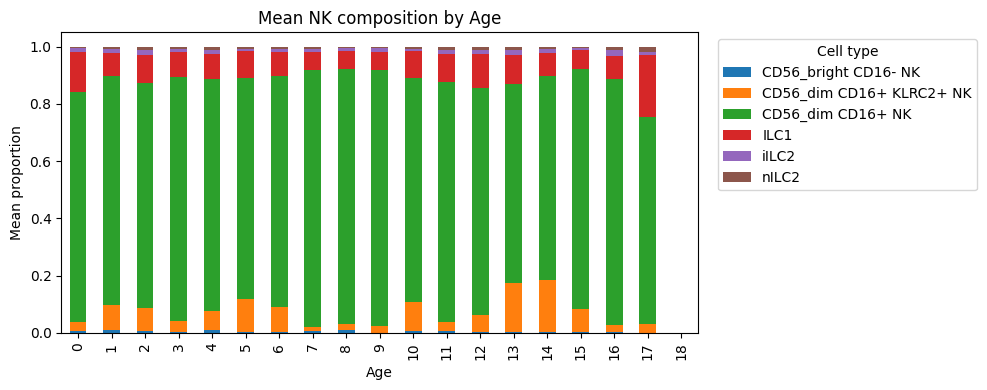

In [34]:
# barplot of composition by age group
props_age = props.join(meta["Age"]).groupby("Age").mean().reindex(range(0, 19))

ax = props_age.plot(kind="bar", stacked=True, figsize=(10, 4))
ax.set_xlabel("Age")
ax.set_ylabel("Mean proportion")
ax.set_title("Mean NK composition by Age")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Cell type")
plt.tight_layout()
plt.show()

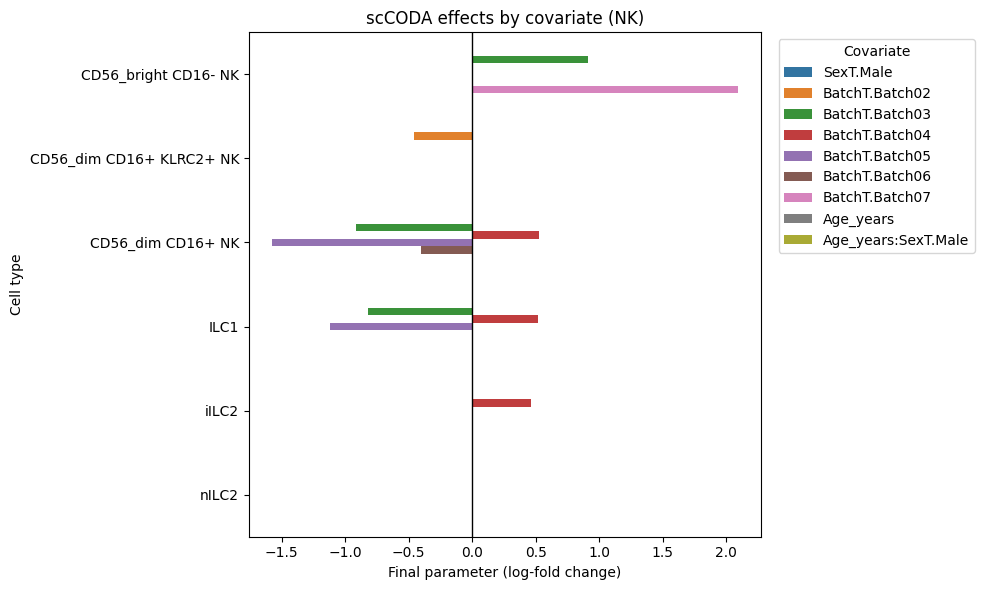

In [ ]:
# effect barplot (may need to check your pertpy version)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=effects_nk_auto,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    orient="h"
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Final parameter (log-fold change)")
plt.ylabel("Cell type")
plt.title("scCODA effects by covariate (NK), ref=nILC2")
plt.legend(title="Covariate", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

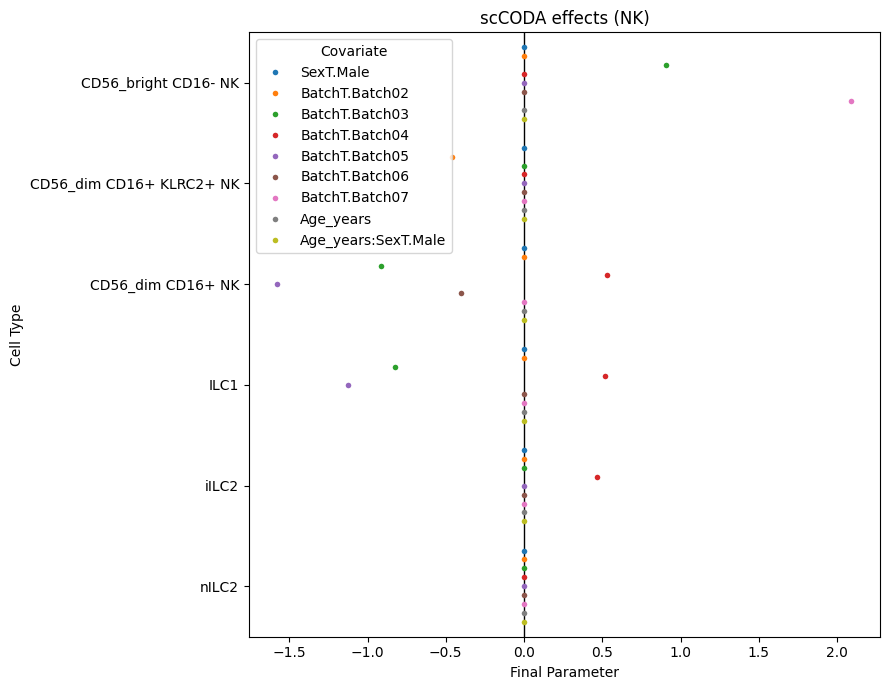

In [ ]:
plt.figure(figsize=(9, 7))
sns.stripplot(
    data=effects_nk_auto,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    dodge=True,
    orient="h",
    size=4
)
plt.axvline(0, color="black", linewidth=1)
plt.title("scCODA effects (NK), ref=nILC2")
plt.tight_layout()
plt.show()

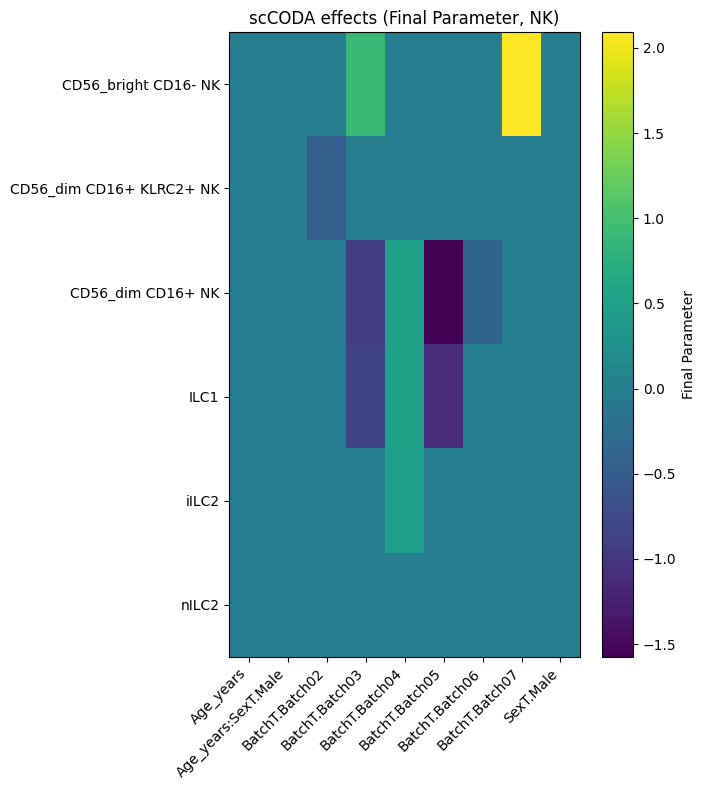

In [ ]:
# inclusion pronbability heatmap
tmp_auto = effects_nk_auto.reset_index()
ip_auto = tmp_auto.pivot(index="Cell Type", columns="Covariate", values="Inclusion probability")

beta_auto = effects_nk_auto["Final Parameter"].unstack("Covariate")

plt.figure(figsize=(7, 8))
plt.imshow(beta_auto.values, aspect="auto")
plt.yticks(range(beta_auto.shape[0]), beta_auto.index)
plt.xticks(range(beta_auto.shape[1]), beta_auto.columns, rotation=45, ha="right")
plt.colorbar(label="Final Parameter")
plt.title("scCODA effects (Final Parameter, NK), ref = nILC2")
plt.tight_layout()
plt.show()

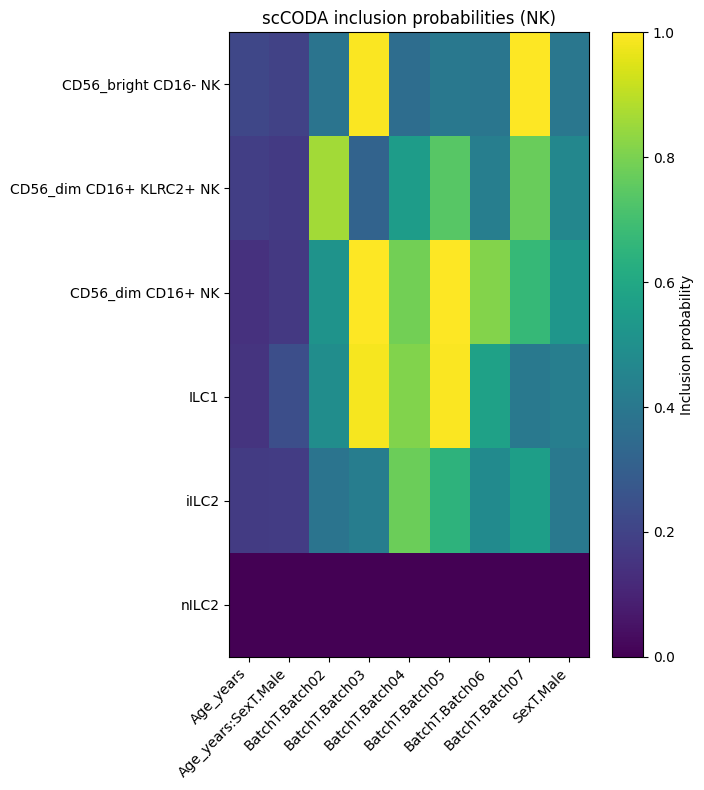

In [ ]:
ip_auto = effects_nk_auto["Inclusion probability"].unstack("Covariate")
# now rows = Cell Type, cols = Covariate

plt.figure(figsize=(7, 8))
plt.imshow(ip_auto.values, aspect="auto")
plt.yticks(range(ip_auto.shape[0]), ip_auto.index)
plt.xticks(range(ip_auto.shape[1]), ip_auto.columns, rotation=45, ha="right")
plt.colorbar(label="Inclusion probability")
plt.title("scCODA inclusion probabilities (NK), ref=nILC2")
plt.tight_layout()
plt.show()

#### ref cell type model (CD56_dim CD16+ NK)

In [32]:
nk_dim = prepare_sccoda_age(sccoda_nk.copy(), ref="CD56_dim CD16+ NK")

• Zero counts encountered in data! Added a pseudocount of 0.5.


In [33]:
nk_dim = run_sccoda(nk_dim, rng_key=2)

warmup:   1%|          | 56/7000 [00:05<12:57,  8.93it/s, 511 steps of size 1.11e-02. acc. prob=0.75] 

sample: 100%|██████████| 7000/7000 [09:51<00:00, 11.83it/s, 511 steps of size 8.25e-03. acc. prob=0.84] 


In [34]:
sccoda_model.summary(nk_dim, modality_key="coda", extended=True)

                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 128 samples, 6 cell types                                         │
│ Reference cell type                   │ CD56_dim CD16+ NK                                                       │
│ Formula                               │ Age_years * Sex + Batch                                                 │
│ Reference index                       │ 2                                                                       │
│ Spike-and-slab threshold              │ 0.913                                                                   │
│ Spike-and-slab threshold              │ 0.913                                                                   │
│ MCMC Sampling                         │ Sampled 5000 chain states (2000 burnin samples)                         │
│ Acceptance rate                       │ 83.6%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                           Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample               │
│ pica_cell_type_complete_01_gdT_corrected                                                                        │
│ CD56_bright CD16- NK                          -1.479       -1.760  -1.215  0.146       10.447                   │
│ CD56_dim CD16+ KLRC2+ NK                       0.433       -0.103   1.006  0.332       70.691                   │
│ CD56_dim CD16+ NK                              3.364        3.231   3.494  0.070     1325.200                   │
│ ILC1                                           1.194        1.010   1.390  0.102      151.308                   │
│ iILC2                                         -0.250       -0.461  -0.031  0.114       35.706                   │
│ nILC2                                         -0.501       -0.735  -0.256  0.125       27.780                   │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                               Final Parameter  Expected Sample  log2-fold change                │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD56_bright CD16- NK          0.000             10.447            0.000                     │
│                     CD56_dim CD16+ KLRC2+ NK      0.000             70.691            0.000                     │
│                     CD56_dim CD16+ NK             0.000           1325.200            0.000                     │
│                     ILC1                          0.000            151.308            0.000                     │
│                     iILC2                         0.000             35.706            0.000                     │
│                     nILC2                         0.000             27.780            0.000                     │
│ BatchT.Batch02      CD56_bright CD16- NK          0.000             10.447            0.000                     │
│                     CD56_dim CD16+ KLRC2+ NK      0.000             70.691            0.000                     │
│                     CD56_dim CD16+ NK             0.000           1325.200            0.000                     │
│                     ILC1                          0.000            151.308            0.000                     │
│                     iILC2                         0.000             35.706            0.000                     │
│                     nILC2                         0.000             27.780            0.000                     │
│ BatchT.Batch03      CD56_bright CD16- NK          1.159             31.340            1.585                     │
│                     CD56_dim CD16+ KLRC2+ NK      0.741            139.647            0.982                     │
│                     CD56_dim CD16+ NK             0.000           1247.884           -0.087                     │
│                     ILC1                          0.000            142.480           -0.087                     │
│                     iILC2                         0.000             33.623           -0.087                     │
│                     nILC2                         0.000             26.159           -0.087                     │
│ BatchT.Batch04      CD56_bright CD16- NK          0.000             10.447            0.000                     │
│                     CD56_dim CD16+ KLRC2+ NK      0.000             70.691            0.000                     │
│                     CD56_dim CD16+ NK             0.000           1325.200            0.000                     │
│                     ILC1                          0.000            151.308            0.000                     │
│                     iILC2                         0.000             35.706            0.000                     │
│                     nILC2                         0.000             27.780            0.000                     │
│ BatchT.Batch05      CD56_bright CD16- NK          0.000              8.697           -0.264                     │
│                     CD56_dim CD16+ KLRC2+ NK      1.725            330.344            2.224                     │
│                     CD56_dim CD16+ NK             0.000           1103.269           -0.264                     │
│                     ILC1                          0.000            125.969           -0.264                     │
│                     iILC2                         0.000             29.726           -0.264                     │
│                     nILC2                         0.00

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                               HDI 3%  HDI 97%   SD   Inclusion probability                      │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD56_bright CD16- NK      -0.234  0.197   0.070         0.402                               │
│                     CD56_dim CD16+ KLRC2+ NK  -0.137  0.203   0.056         0.381                               │
│                     CD56_dim CD16+ NK          0.000  0.000   0.000         0.000                               │
│                     ILC1                      -0.250  0.067   0.073         0.462                               │
│                     iILC2                     -0.207  0.168   0.062         0.382                               │
│                     nILC2                     -0.348  0.119   0.095         0.456                               │
│ BatchT.Batch02      CD56_bright CD16- NK      -0.451  0.245   0.119         0.377                               │
│                     CD56_dim CD16+ KLRC2+ NK  -1.070  0.093   0.375         0.744                               │
│                     CD56_dim CD16+ NK          0.000  0.000   0.000         0.000                               │
│                     ILC1                      -0.170  0.236   0.058         0.316                               │
│                     iILC2                     -0.553  0.096   0.166         0.491                               │
│                     nILC2                     -0.314  0.259   0.090         0.352                               │
│ BatchT.Batch03      CD56_bright CD16- NK       0.696  1.583   0.226         1.000                               │
│                     CD56_dim CD16+ KLRC2+ NK   0.135  1.279   0.364         0.914                               │
│                     CD56_dim CD16+ NK          0.000  0.000   0.000         0.000                               │
│                     ILC1                      -0.372  0.108   0.080         0.259                               │
│                     iILC2                     -0.202  0.451   0.103         0.275                               │
│                     nILC2                     -0.311  0.385   0.089         0.247                               │
│ BatchT.Batch04      CD56_bright CD16- NK      -0.386  0.308   0.113         0.379                               │
│                     CD56_dim CD16+ KLRC2+ NK  -1.079  0.069   0.366         0.742                               │
│                     CD56_dim CD16+ NK          0.000  0.000   0.000         0.000                               │
│                     ILC1                      -0.145  0.232   0.058         0.312                               │
│                     iILC2                     -0.281  0.269   0.083         0.349                               │
│                     nILC2                     -0.207  0.401   0.103         0.381                               │
│ BatchT.Batch05      CD56_bright CD16- NK      -0.542  0.447   0.132         0.255                               │
│                     CD56_dim CD16+ KLRC2+ NK   1.110  2.273   0.337         1.000                               │
│                     CD56_dim CD16+ NK          0.000  0.000   0.000         0.000                               │
│                     ILC1                      -0.159  0.340   0.067         0.193                               │
│                     iILC2                     -0.267  0.565   0.131         0.283                               │
│                     nILC2                     -0.311  

In [35]:
# set desired FDR globally
sccoda_model.set_fdr(nk_dim, est_fdr=0.1, modality_key="coda")

In [36]:
# check threshold
nk_dim["coda"].uns["scCODA_params"]["threshold_prob"]

np.float64(0.743)

In [37]:
effects_nk_dim = sccoda_model.get_effect_df(nk_dim, modality_key="coda")

effects_nk_dim["Inclusion probability"].max()
effects_nk_dim["Inclusion probability"].describe()

count    54.000000
mean      0.337163
std       0.262407
min       0.000000
25%       0.196100
50%       0.281900
75%       0.418100
max       1.000000
Name: Inclusion probability, dtype: float64

In [38]:

# effects dataframe
effects_nk_dim = sccoda_model.get_effect_df(nk_dim, modality_key="coda")
effects_nk_dim.head()

Final Parameter  HDI 3%  HDI 97%     SD  \
Covariate Cell Type                                                           
SexT.Male CD56_bright CD16- NK                  0.0  -0.234    0.197  0.070   
          CD56_dim CD16+ KLRC2+ NK              0.0  -0.137    0.203  0.056   
          CD56_dim CD16+ NK                     0.0   0.000    0.000  0.000   
          ILC1                                  0.0  -0.250    0.067  0.073   
          iILC2                                 0.0  -0.207    0.168  0.062   

                                    Inclusion probability  Expected Sample  \
Covariate Cell Type                                                          
SexT.Male CD56_bright CD16- NK                     0.4024        10.447043   
          CD56_dim CD16+ KLRC2+ NK                 0.3808        70.691051   
          CD56_dim CD16+ NK                        0.0000      1325.200412   
          ILC1                                     0.4616       151.308225   
          iILC2                                    0.3824        35.706009   

                                    log2-fold change  
Covariate Cell Type                                   
SexT.Male CD56_bright CD16- NK                   0.0  
          CD56_dim CD16+ KLRC2+ NK               0.0  
          CD56_dim CD16+ NK                      0.0  
          ILC1                                   0.0  
          iILC2                                  0.0

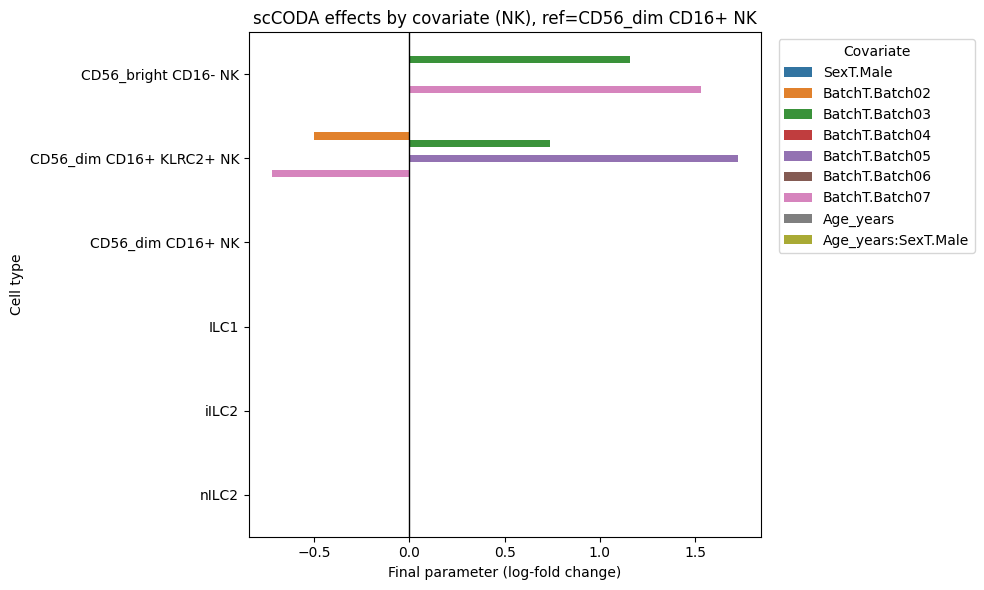

In [39]:
# effect barplot (may need to check your pertpy version)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=effects_nk_dim,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    orient="h"
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Final parameter (log-fold change)")
plt.ylabel("Cell type")
plt.title("scCODA effects by covariate (NK), ref=CD56_dim CD16+ NK")
plt.legend(title="Covariate", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

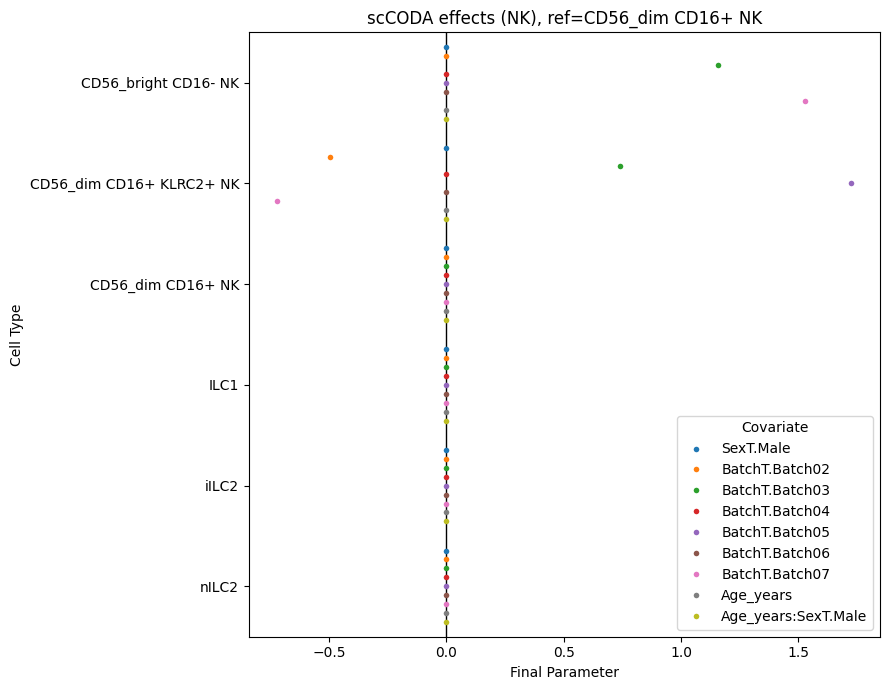

In [40]:
plt.figure(figsize=(9, 7))
sns.stripplot(
    data=effects_nk_dim,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    dodge=True,
    orient="h",
    size=4
)
plt.axvline(0, color="black", linewidth=1)
plt.title("scCODA effects (NK), ref=CD56_dim CD16+ NK")
plt.tight_layout()
plt.show()

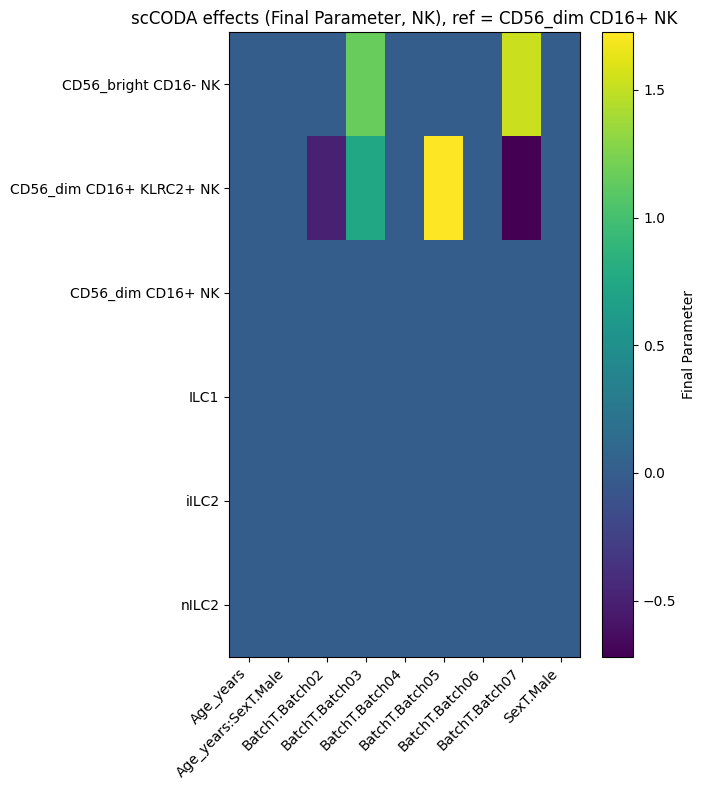

In [41]:
# inclusion pronbability heatmap
tmp_dim = effects_nk_dim.reset_index()
ip_dim = tmp_dim.pivot(index="Cell Type", columns="Covariate", values="Inclusion probability")

beta_dim = effects_nk_dim["Final Parameter"].unstack("Covariate")

plt.figure(figsize=(7, 8))
plt.imshow(beta_dim.values, aspect="auto")
plt.yticks(range(beta_dim.shape[0]), beta_dim.index)
plt.xticks(range(beta_dim.shape[1]), beta_dim.columns, rotation=45, ha="right")
plt.colorbar(label="Final Parameter")
plt.title("scCODA effects (Final Parameter, NK), ref = CD56_dim CD16+ NK")
plt.tight_layout()
plt.show()

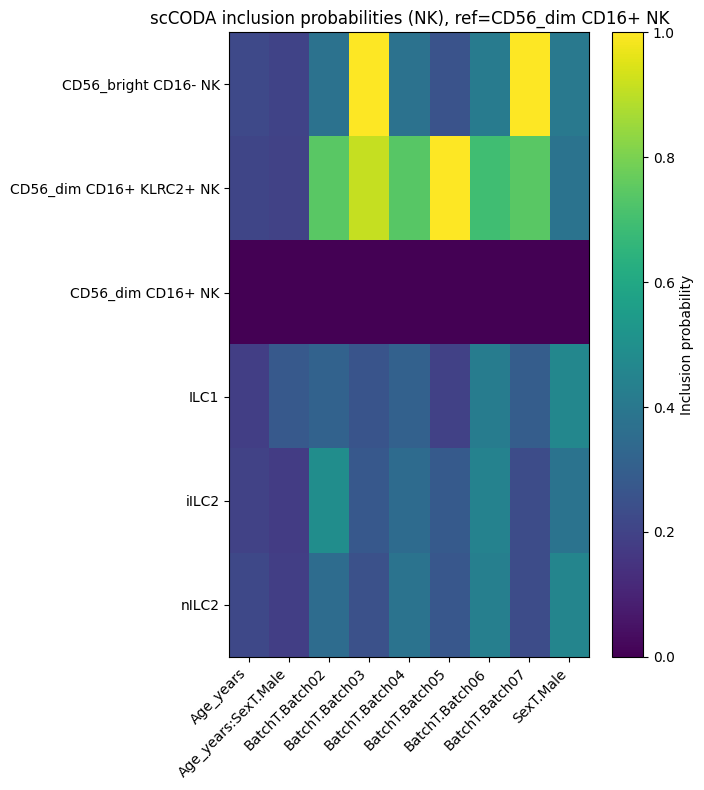

In [42]:
ip_dim = effects_nk_dim["Inclusion probability"].unstack("Covariate")
# now rows = Cell Type, cols = Covariate

plt.figure(figsize=(7, 8))
plt.imshow(ip_dim.values, aspect="auto")
plt.yticks(range(ip_dim.shape[0]), ip_dim.index)
plt.xticks(range(ip_dim.shape[1]), ip_dim.columns, rotation=45, ha="right")
plt.colorbar(label="Inclusion probability")
plt.title("scCODA inclusion probabilities (NK), ref=CD56_dim CD16+ NK")
plt.tight_layout()
plt.show()

#### ref cell type model (CD56_dim CD16+ KLRC2+ NK)

In [22]:
nk_dim_klrc2 = prepare_sccoda_age(sccoda_nk.copy(), ref="CD56_dim CD16+ KLRC2+ NK")

• Zero counts encountered in data! Added a pseudocount of 0.5.


In [23]:
nk_dim_klrc2 = run_sccoda(nk_dim_klrc2, rng_key=3)

sample: 100%|██████████| 7000/7000 [10:52<00:00, 10.73it/s, 511 steps of size 6.73e-03. acc. prob=0.86] 


In [24]:
sccoda_model.summary(nk_dim_klrc2, modality_key="coda", extended=True)

                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 128 samples, 6 cell types                                         │
│ Reference cell type                   │ CD56_dim CD16+ KLRC2+ NK                                                │
│ Formula                               │ Age_years * Sex + Batch                                                 │
│ Reference index                       │ 1                                                                       │
│ Spike-and-slab threshold              │ 0.788                                                                   │
│ Spike-and-slab threshold              │ 0.788                                                                   │
│ MCMC Sampling                         │ Sampled 5000 chain states (2000 burnin samples)                         │
│ Acceptance rate                       │ 85.5%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                           Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample               │
│ pica_cell_type_complete_01_gdT_corrected                                                                        │
│ CD56_bright CD16- NK                          -1.346       -1.640  -1.014  0.166        9.221                   │
│ CD56_dim CD16+ KLRC2+ NK                       0.790        0.647   0.946  0.080       78.057                   │
│ CD56_dim CD16+ NK                              3.630        3.226   4.164  0.240     1336.007                   │
│ ILC1                                           1.435        0.967   1.918  0.235      148.776                   │
│ iILC2                                         -0.203       -0.580   0.165  0.201       28.917                   │
│ nILC2                                         -0.564       -0.966  -0.132  0.224       20.155                   │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                               Final Parameter  Expected Sample  log2-fold change                │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD56_bright CD16- NK           0.000             9.221            0.000                     │
│                     CD56_dim CD16+ KLRC2+ NK       0.000            78.057            0.000                     │
│                     CD56_dim CD16+ NK              0.000          1336.007            0.000                     │
│                     ILC1                           0.000           148.776            0.000                     │
│                     iILC2                          0.000            28.917            0.000                     │
│                     nILC2                          0.000            20.155            0.000                     │
│ BatchT.Batch02      CD56_bright CD16- NK           0.000             5.044           -0.870                     │
│                     CD56_dim CD16+ KLRC2+ NK       0.000            42.701           -0.870                     │
│                     CD56_dim CD16+ NK              0.647          1395.434            0.063                     │
│                     ILC1                           0.569           143.801           -0.049                     │
│                     iILC2                          0.000            15.819           -0.870                     │
│                     nILC2                          0.508            18.333           -0.137                     │
│ BatchT.Batch03      CD56_bright CD16- NK           0.822            38.524            2.063                     │
│                     CD56_dim CD16+ KLRC2+ NK       0.000           143.307            0.877                     │
│                     CD56_dim CD16+ NK             -0.707          1209.738           -0.143                     │
│                     ILC1                          -0.672           139.471           -0.093                     │
│                     iILC2                          0.000            53.090            0.877                     │
│                     nILC2                          0.000            37.003            0.877                     │
│ BatchT.Batch04      CD56_bright CD16- NK           0.000             3.568           -1.370                     │
│                     CD56_dim CD16+ KLRC2+ NK       0.000            30.207           -1.370                     │
│                     CD56_dim CD16+ NK              0.995          1398.230            0.066                     │
│                     ILC1                           0.935           146.600           -0.021                     │
│                     iILC2                          0.740            23.445           -0.303                     │
│                     nILC2                          0.895            19.083           -0.079                     │
│ BatchT.Batch05      CD56_bright CD16- NK           0.000            33.457            1.859                     │
│                     CD56_dim CD16+ KLRC2+ NK       0.000           283.231            1.859                     │
│                     CD56_dim CD16+ NK             -1.624           955.290           -0.484                     │
│                     ILC1                          -1.149           171.097            0.202                     │
│                     iILC2                          0.000           104.927            1.859                     │
│                     nILC2                          0.0

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                               HDI 3%  HDI 97%   SD   Inclusion probability                      │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD56_bright CD16- NK      -0.256   0.202  0.076         0.414                               │
│                     CD56_dim CD16+ KLRC2+ NK   0.000   0.000  0.000         0.000                               │
│                     CD56_dim CD16+ NK         -0.034   0.220  0.065         0.515                               │
│                     ILC1                      -0.227   0.087  0.064         0.429                               │
│                     iILC2                     -0.219   0.183  0.064         0.379                               │
│                     nILC2                     -0.320   0.128  0.088         0.442                               │
│ BatchT.Batch02      CD56_bright CD16- NK      -0.442   0.441  0.138         0.355                               │
│                     CD56_dim CD16+ KLRC2+ NK   0.000   0.000  0.000         0.000                               │
│                     CD56_dim CD16+ NK          0.090   1.123  0.291         0.937                               │
│                     ILC1                      -0.008   1.004  0.294         0.917                               │
│                     iILC2                     -0.219   0.731  0.203         0.464                               │
│                     nILC2                     -0.012   0.971  0.321         0.789                               │
│ BatchT.Batch03      CD56_bright CD16- NK       0.325   1.245  0.250         0.993                               │
│                     CD56_dim CD16+ KLRC2+ NK   0.000   0.000  0.000         0.000                               │
│                     CD56_dim CD16+ NK         -1.268  -0.274  0.260         0.992                               │
│                     ILC1                      -1.218  -0.178  0.283         0.968                               │
│                     iILC2                     -0.719   0.246  0.201         0.430                               │
│                     nILC2                     -0.706   0.341  0.201         0.405                               │
│ BatchT.Batch04      CD56_bright CD16- NK      -0.350   0.599  0.147         0.318                               │
│                     CD56_dim CD16+ KLRC2+ NK   0.000   0.000  0.000         0.000                               │
│                     CD56_dim CD16+ NK          0.415   1.454  0.273         0.998                               │
│                     ILC1                       0.378   1.450  0.274         0.997                               │
│                     iILC2                      0.195   1.206  0.285         0.965                               │
│                     nILC2                      0.359   1.396  0.289         0.988                               │
│ BatchT.Batch05      CD56_bright CD16- NK      -0.962   0.113  0.304         0.517                               │
│                     CD56_dim CD16+ KLRC2+ NK   0.000   0.000  0.000         0.000                               │
│                     CD56_dim CD16+ NK         -2.241  -1.089  0.292         1.000                               │
│                     ILC1                      -1.748  -0.482  0.315         1.000                               │
│                     iILC2                     -1.090   0.006  0.365         0.699                               │
│                     nILC2                     -1.041  

In [25]:
# set desired FDR globally
sccoda_model.set_fdr(nk_dim_klrc2, est_fdr=0.1, modality_key="coda")

In [26]:
# check threshold
nk_dim_klrc2["coda"].uns["scCODA_params"]["threshold_prob"]

np.float64(0.699)

In [27]:
effects_nk_dim_klrc2 = sccoda_model.get_effect_df(nk_dim_klrc2, modality_key="coda")

effects_nk_dim_klrc2["Inclusion probability"].max()
effects_nk_dim_klrc2["Inclusion probability"].describe()

count    54.000000
mean      0.487844
std       0.363004
min       0.000000
25%       0.174750
50%       0.436300
75%       0.908300
max       1.000000
Name: Inclusion probability, dtype: float64

In [28]:

# effects dataframe
effects_nk_dim_klrc2 = sccoda_model.get_effect_df(nk_dim_klrc2, modality_key="coda")
effects_nk_dim_klrc2.head()

Final Parameter  HDI 3%  HDI 97%     SD  \
Covariate Cell Type                                                           
SexT.Male CD56_bright CD16- NK                  0.0  -0.256    0.202  0.076   
          CD56_dim CD16+ KLRC2+ NK              0.0   0.000    0.000  0.000   
          CD56_dim CD16+ NK                     0.0  -0.034    0.220  0.065   
          ILC1                                  0.0  -0.227    0.087  0.064   
          iILC2                                 0.0  -0.219    0.183  0.064   

                                    Inclusion probability  Expected Sample  \
Covariate Cell Type                                                          
SexT.Male CD56_bright CD16- NK                     0.4138         9.220606   
          CD56_dim CD16+ KLRC2+ NK                 0.0000        78.057109   
          CD56_dim CD16+ NK                        0.5152      1336.007176   
          ILC1                                     0.4288       148.775837   
          iILC2                                    0.3792        28.917320   

                                    log2-fold change  
Covariate Cell Type                                   
SexT.Male CD56_bright CD16- NK                   0.0  
          CD56_dim CD16+ KLRC2+ NK               0.0  
          CD56_dim CD16+ NK                      0.0  
          ILC1                                   0.0  
          iILC2                                  0.0

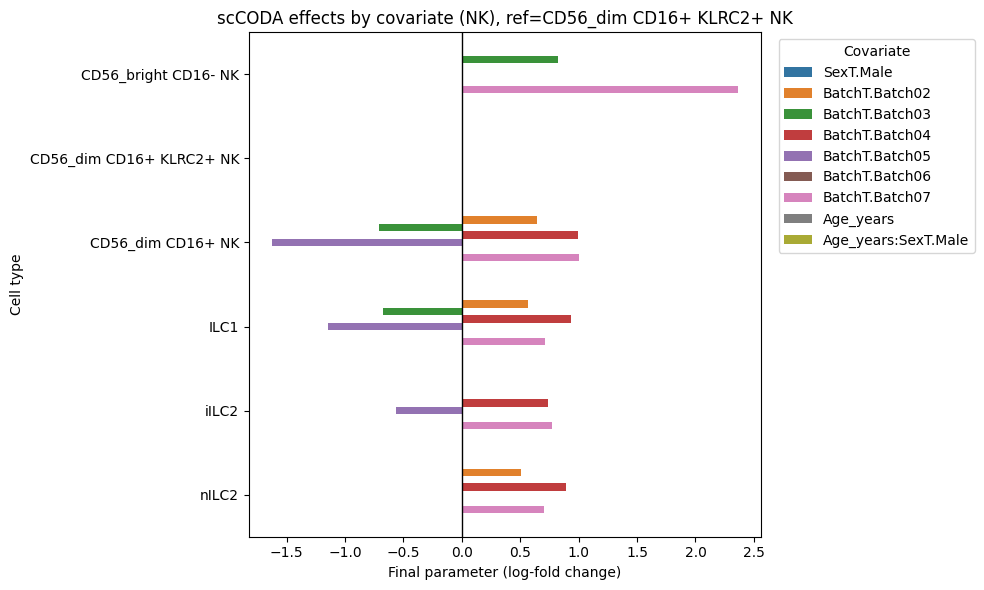

In [29]:
# effect barplot (may need to check your pertpy version)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=effects_nk_dim_klrc2,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    orient="h"
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Final parameter (log-fold change)")
plt.ylabel("Cell type")
plt.title("scCODA effects by covariate (NK), ref=CD56_dim CD16+ KLRC2+ NK")
plt.legend(title="Covariate", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

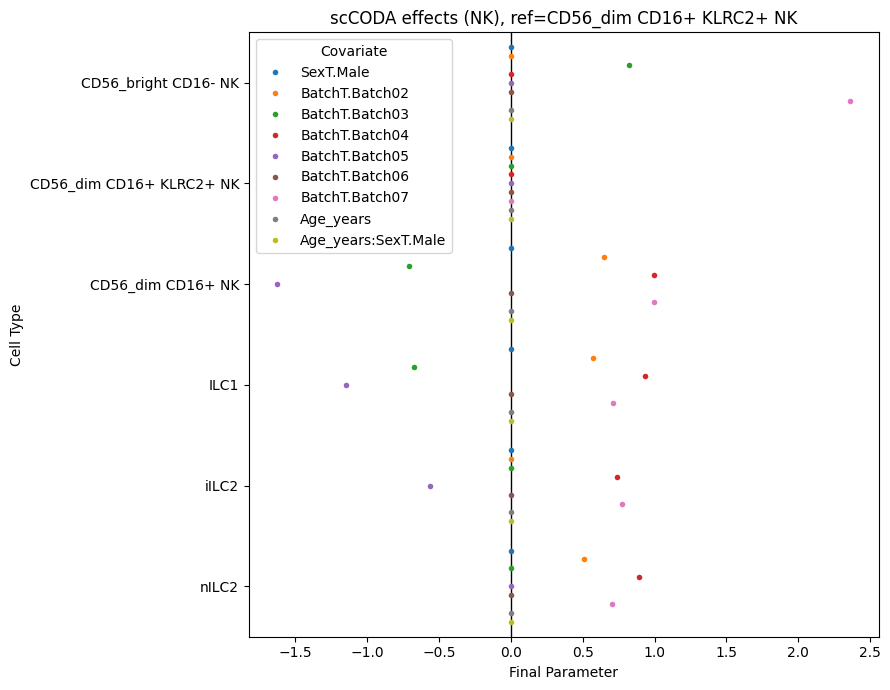

In [30]:
plt.figure(figsize=(9, 7))
sns.stripplot(
    data=effects_nk_dim_klrc2,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    dodge=True,
    orient="h",
    size=4
)
plt.axvline(0, color="black", linewidth=1)
plt.title("scCODA effects (NK), ref=CD56_dim CD16+ KLRC2+ NK")
plt.tight_layout()
plt.show()

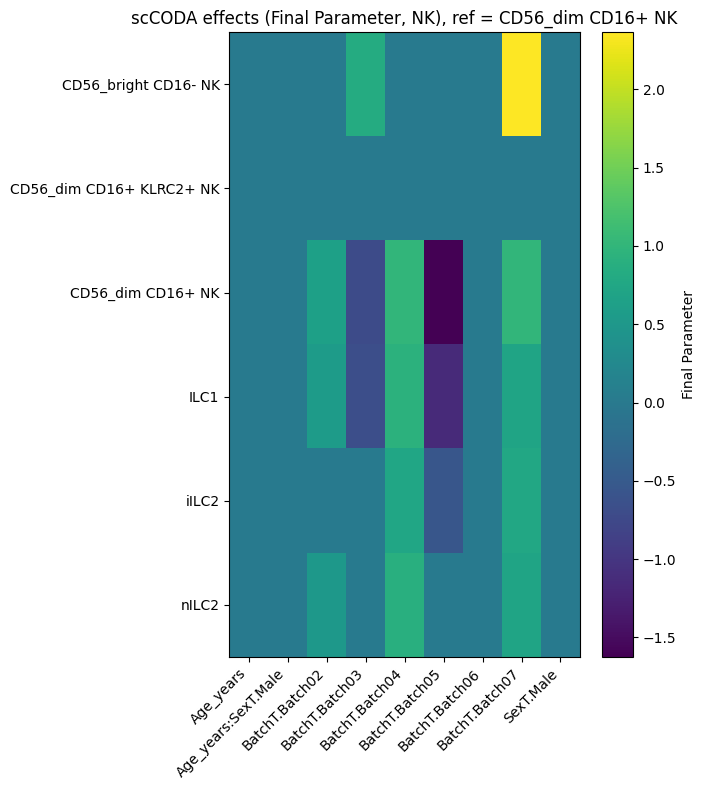

In [31]:
# inclusion pronbability heatmap
tmp_dim_klrc2 = effects_nk_dim_klrc2.reset_index()
ip_dim_klrc2 = tmp_dim_klrc2.pivot(index="Cell Type", columns="Covariate", values="Inclusion probability")

beta_dim_klrc2 = effects_nk_dim_klrc2["Final Parameter"].unstack("Covariate")

plt.figure(figsize=(7, 8))
plt.imshow(beta_dim_klrc2.values, aspect="auto")
plt.yticks(range(beta_dim_klrc2.shape[0]), beta_dim_klrc2.index)
plt.xticks(range(beta_dim_klrc2.shape[1]), beta_dim_klrc2.columns, rotation=45, ha="right")
plt.colorbar(label="Final Parameter")
plt.title("scCODA effects (Final Parameter, NK), ref = CD56_dim CD16+ NK")
plt.tight_layout()
plt.show()

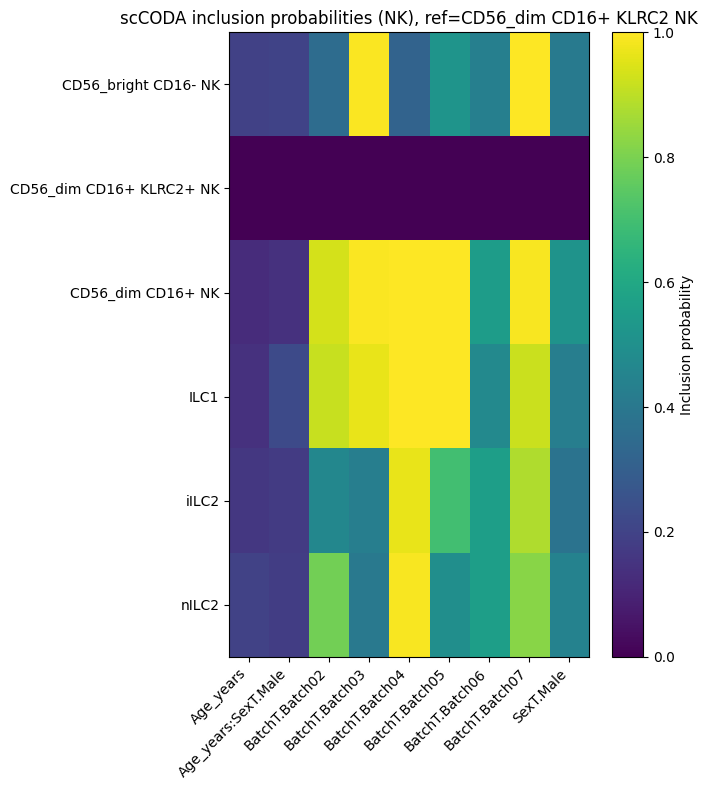

In [32]:
ip_dim_klrc2 = effects_nk_dim_klrc2["Inclusion probability"].unstack("Covariate")
# now rows = Cell Type, cols = Covariate

plt.figure(figsize=(7, 8))
plt.imshow(ip_dim_klrc2.values, aspect="auto")
plt.yticks(range(ip_dim_klrc2.shape[0]), ip_dim_klrc2.index)
plt.xticks(range(ip_dim_klrc2.shape[1]), ip_dim_klrc2.columns, rotation=45, ha="right")
plt.colorbar(label="Inclusion probability")
plt.title("scCODA inclusion probabilities (NK), ref=CD56_dim CD16+ KLRC2 NK")
plt.tight_layout()
plt.show()